# Self RAG

- The knowledgebase contains 3 documents which are related to 
    - Companies policy
    - Leave Policy
    - Benefits
- Workflow
    - When user asks question, first we will need a decider node which decides on whether this question can be answered without any retrieval or not
    - If the documents are retrieved then we check if each of the documents are relevant to answer the question or not
    - Those documents which are relevant will be retained and the rest will be ignored
    - If there are relevant documents then we use those documents to answer the question, else we say that there are no relevant documents
    - Currently there is a seperate node created to return "No relevant documents present", this can futher be extended to web search
    - With the answers provided by the LLM, we verify if the response has been halucinated or not by classifying the response as fully_supported, partially_supported or no_support
    - If its fully_supported then we end the workflow, else we try to regenrate the answer again given the context
    - When we do regeneration we might get into an infinite loop, thus we will need to maintain the max no of retries allowed




In [1]:
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import START, END, StateGraph
from typing import Annotated, TypedDict, List, Literal
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

/Users/ritumalage/Documents/my_github/Notes/.venv_langgraph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading the documents
docs = (PyPDFLoader("./utils/companies_policy.pdf").load() 
+ PyPDFLoader("./utils/leave_policy.pdf").load()
+ PyPDFLoader("./utils/benefits.pdf").load()
)
docs

[Document(metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'paper_trial', 'source': './utils/companies_policy.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Company  Policies  &  Employee  \nHandbook\n \nChapter  1:  Introduction  \n●  Mission  Statement :  Our  mission  is  to  deliver  \ninnovative\n \nsolutions\n \nthat\n \nimprove\n \nlives\n \nwhile\n \nfostering\n \na\n \nculture\n \nof\n \nintegrity\n \nand\n \ncollaboration.\n ●  Vision :  To  be  recognized  globally  as  a  sustainable,  \nethical,\n \nand\n \nemployee-centric\n \norganization.\n ●  Core  Values :  ○  Integrity:  Acting  honestly  in  all  dealings.  ○  Collaboration:  Working  together  across  teams  \nand\n \ngeographies.\n ○  Innovation:  Encouraging  creativity  and  \ncontinuous\n \nimprovement.\n ○  Accountability:  Taking  responsibility  for  actions  \nand\n \noutcomes.\n ○  Respect:  Valuing  diversity  and  treating 

# Splitting the documents into chunks

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 200).split_documents(documents=docs)
chunks

[Document(metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'paper_trial', 'source': './utils/companies_policy.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Company  Policies  &  Employee  \nHandbook\n \nChapter  1:  Introduction  \n●  Mission  Statement :  Our  mission  is  to  deliver  \ninnovative\n \nsolutions\n \nthat\n \nimprove\n \nlives\n \nwhile\n \nfostering\n \na\n \nculture\n \nof\n \nintegrity\n \nand\n \ncollaboration.\n ●  Vision :  To  be  recognized  globally  as  a  sustainable,  \nethical,\n \nand\n \nemployee-centric\n \norganization.\n ●  Core  Values :  ○  Integrity:  Acting  honestly  in  all  dealings.  ○  Collaboration:  Working  together  across  teams  \nand'),
 Document(metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'paper_trial', 'source': './utils/companies_policy.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1

# Embedding

In [4]:
from langchain_community.embeddings import HuggingFaceEmbeddings
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = FAISS.from_documents(chunks, embedding_model)

retriever = vector_store.as_retriever(search_kwargs={"k": 4})


/var/folders/7h/94sb5d7d299gb4rg29gqcqhm0000gn/T/ipykernel_1659/11024232.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10319.69it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
model = ChatGroq(model = "qwen/qwen3-32b") 

# Defining the state
- Based on the value of `need_retrieval` we will decide on whether documents must be retrieved or not

In [6]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    # Stores all the retrieved documents
    docs: List[Document]

    # To store all the relevant documents
    relevant_docs: List[Document]
    
    
    # Store LLMs response
    answer: str 

    # Merges all the relevant docs and the passes it as a context to the LLM
    context: str

    # Post generation verification
    is_supported: Literal["fully_supported", "partially_supported", "no_support"]

    # Maintaining the no of retries
    retries: int

    

# Defining the pydantic model 
- So that we can fetch the answer on whether retrieval is required or not and store its result in the state variable `need_retrieval` 

In [7]:
from langchain.messages import SystemMessage


class RetrievalDecision(BaseModel):
    should_retrieve: bool = Field(description="True if external documents must be fetched to answer the users query reliably, else False")


decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessage(content="When the users question revolves around the company then return True else return False for any generic question asked by the user"),
        HumanMessage(content="Question: {question}")
    ]
)

# Pydantic LLM
should_retrieve_llm = model.with_structured_output(RetrievalDecision)



# Defining the Function for decider node

In [8]:
def decider_node(state: State):
    decision = should_retrieve_llm.invoke(decide_retrieval_prompt.format_messages(question = state["question"]))
    print("DECISION", decision)
    return {"need_retrieval": decision.should_retrieve}

### Flow of execution
- Users question: What is LangGraph?
- State gets updated question: What is LangGraph?
- Prompt construction
    - decide_retrieval_prompt = SystemMessage: You are an expert who can decide whether the relevant documents must be retrieved...
    HumanMessage: Question: What is LangGraph?
- This prompt is passed to the LLM should_retrieve_llm which is forced to return an output should_retrieve as True or False
- The response of the LLM will be in a JSON format
{
    "should_retrieve": True
}
- Thus final response should be llm_response.should_retrieve


# Function definition for generating the response directly via LLM

In [9]:
def direct_llm_response_node(state: State):
    
    prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content = "Answer the given question using your general knowledge"),
        HumanMessage(content= "Question: {question}")
    ])
    response = model.invoke(prompt.format_messages(question = state["question"]))

    return {"answer": response.content}

# Function definition for retrieving the relevant documents

In [10]:
def retrieve_node(state: State):
    return {"docs": retriever.invoke(state["question"])}
    

# Function to check if the retrieved documents are relevant or not

In [11]:
# Defining the pydantic Schema
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(description="Return True if the documents are relevant in answering the question else False")

# Defining the prompt that will be used to pass to the LLM
is_relevant_prompt = ChatPromptTemplate.from_messages([
    SystemMessage(content = "You are judging the document relevance. Return True if the document is relevant in answering the users question, else return False"),
    HumanMessage(content = "Question: {question} and Document: {document}")
])

relevance_llm = model.with_structured_output(RelevanceDecision)

# Defining the function for the node
def is_relevant_node(state: State):
    # Storing the list of relevant documents 
    relevant_docs: list[Document] = []

    for doc in state["docs"]:
        decision = relevance_llm.invoke(is_relevant_prompt.format_messages(question = state["question"], document = doc.page_content))

        if decision.is_relevant:
            relevant_docs.append(doc)
    
    return {"relevant_docs": relevant_docs}

# Routing function

In [12]:
def route_after_retrieval_decision(state:State) -> Literal["retrieve_node", "direct_llm_response_node"]:
    if state["need_retrieval"]:
        return "retrieve_node"
    else:
        return "direct_llm_response_node"

# Defining the function to check whether the response is halucinated or not 
- We clarify it as whether its fully supported, partially supported, or no support

In [13]:
class is_up_decision(BaseModel):
    supporting_type: Literal["fully_supported", "partially_supported", "no_support"]


is_supported_prompt = ChatPromptTemplate.from_messages([
    SystemMessage(content = """You are verifying if the 
    - Given the question, answer, and context verify if the answer is fully relevant to the users query based on the context, if yes then return fully_supported,
    If its partially supported then return partially_supported else return no_support
    """),
    HumanMessage(content = "Question: {question}, Context: {context} and Answer: {answer}")
]) 

is_supported_llm = model.with_structured_output(is_up_decision)

def is_supported_node(state: State):
    prompt = is_supported_prompt.format_messages(
        question = state["question"],
        answer = state["answer"],
        context = state["context"]
    )

    decision = is_supported_llm.invoke(prompt)
    print(f"Support Type: {decision.supporting_type}")

    return {"is_supported": decision.supporting_type}



# Defining the function for revising the prompt

In [14]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessage(content="You are a strict reviser, You need to revise the response based on given question, current answer and the context. Just answer to the point"),
        HumanMessage(content="Answer:{answer} Question: {question} Context: {context}")
    ]
)

def revise_node(state: State):
    response = model.invoke(revise_prompt.format_messages(
        question = state["question"],
        answer=state["answer"],
        context=state["context"]

    ))
    return {
        "answer": response.content,
        "retries": state.get("retries", 0) +1 
    }
    

# Defining the function for generating answers given the context

In [15]:
from langgraph.graph.message import _format_messages


def generate_from_context_node(state: State):
    context = ""
    for document in state["relevant_docs"]:
        context = context+" "+ document.page_content

    
    prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content="Answer the given question using the given context"),
        HumanMessage(content = "Question: {question}, context: {context}")
    ])
    print("CONTEXT", len(context))
    
    response = model.invoke(prompt.format_messages(question = state["question"], context = context))
    
    return {"context": context, "answer": response.content}
    

# Defining the function when No relevant docs exists

In [16]:
def no_relevant_docs_node(state: State):
    return {"answer": "No relevant documents", "context":""}

# Routing function to decide if it has to go to no_relevant_docs_node or generate_from_context_node

In [17]:
def route_after_relevance(state: State)-> Literal["generate_from_context_node", "no_relevant_docs_node"]:
    if len(state["relevant_docs"]) >0:
        return "generate_from_context_node"
    else:
        return "no_relevant_docs_node"

# If answer is accepted we keep it as it is

In [18]:
def accept_answer(state:State):
    return {}

# Routing function for checking if the answer is accepted or it must be revised 
- If it goes beyond the max retries we accept the answer as it is

In [19]:
MAX_RETRIES = 3

def route_after_is_supported(state:State) -> Literal["accept_answer", "revise_answer"]:
    # Accept it if its fully supported
    if state.get("is_supported") == "fully_supported":
        return "accept_answer"
    if state.get("retries",0)>=MAX_RETRIES:
        return "accept_answer"
    return "revise_answer"

# Defining the graph

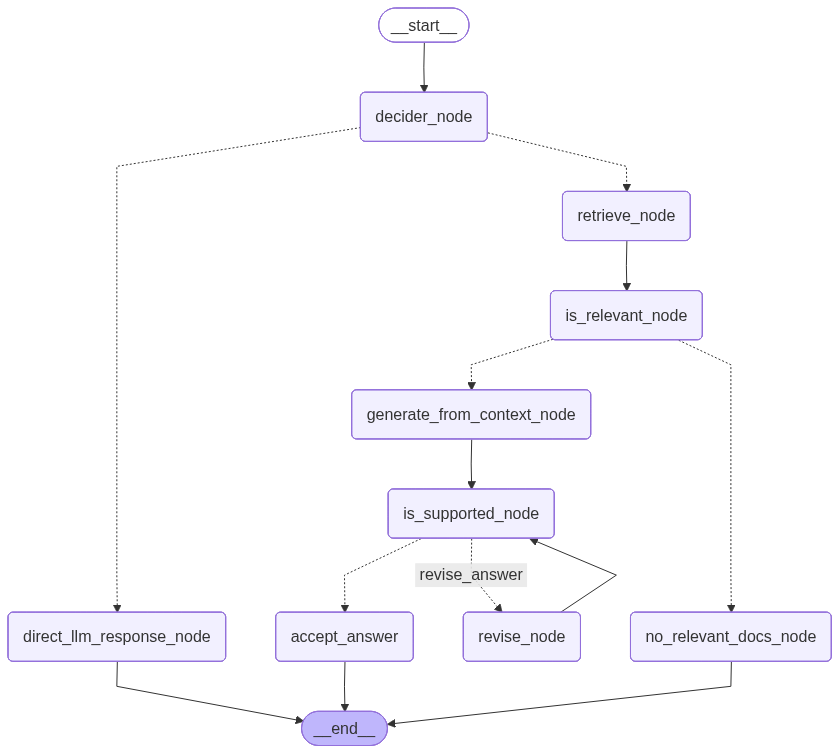

In [20]:
graph = StateGraph(State)

graph.add_node("decider_node", decider_node)
graph.add_node("retrieve_node", retrieve_node)
graph.add_node("direct_llm_response_node", direct_llm_response_node)
graph.add_node("is_relevant_node", is_relevant_node)
graph.add_node("no_relevant_docs_node", no_relevant_docs_node)
graph.add_node("generate_from_context_node", generate_from_context_node)
graph.add_node("is_supported_node", is_supported_node)
graph.add_node("revise_node", revise_node)
graph.add_node("accept_answer", accept_answer)



graph.add_edge(START, "decider_node")
graph.add_conditional_edges("decider_node", route_after_retrieval_decision, {"retrieve_node": "retrieve_node", "direct_llm_response_node":"direct_llm_response_node"})
graph.add_edge("direct_llm_response_node", END)
graph.add_edge("retrieve_node", "is_relevant_node")

graph.add_conditional_edges("is_relevant_node", route_after_relevance, {"generate_from_context_node": "generate_from_context_node", "no_relevant_docs_node": "no_relevant_docs_node"})
# graph.add_edge("is_relevant_node", "generate_from_context_node")
# graph.add_edge("is_relevant_node","no_relevant_docs_node")


graph.add_edge("generate_from_context_node", "is_supported_node")
graph.add_conditional_edges("is_supported_node", route_after_is_supported, {"accept_answer": "accept_answer", "revise_answer": "revise_node"})
# To run in loop
graph.add_edge("revise_node", "is_supported_node")
graph.add_edge("accept_answer", END)

workflow = graph.compile()
workflow

In [21]:
initial_state = {"question": "How many no of meternity and paternity leaves are given?"}

workflow.invoke(initial_state)

DECISION should_retrieve=True
CONTEXT 1238
Support Type: partially_supported
Support Type: fully_supported


{'question': 'How many no of meternity and paternity leaves are given?',
 'need_retrieval': True,
 'docs': [Document(id='3fb8df43-1305-47a6-a76a-4f5e628c5f1b', metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'paper_trial', 'source': './utils/leave_policy.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='●  Case  Study :  Employees  adopting  a  child  under  1  \nyear\n \nare\n \nentitled\n \nto\n \n12\n \nweeks\n \nof\n \nleave.\n \nChapter  4:  Casual  &  Emergency  Leave  \n●  Casual  Leave :  7  days  per  year  for  personal  reasons.  ●  Emergency  Leave :  Immediate  approval  for  family  \nemergencies.\n ●  Scenario :  An  employee  requesting  leave  due  to  a  \nparent’s\n \nhospitalization\n \nwill\n \nbe\n \ngranted\n \nemergency\n \nleave.\n \nChapter  5:  Unpaid  Leave'),
  Document(id='b39994ad-9ff2-49de-b0ed-caae47d943e7', metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creato

In [23]:
initial_state = {"question": "What is LangGraph?"}

workflow.invoke(initial_state)

DECISION should_retrieve=False


{'question': 'What is LangGraph?',
 'need_retrieval': False,
 'answer': "<think>\nOkay, I need to answer the user's question using my general knowledge. Let me start by understanding the question thoroughly. The user mentioned that their answer should demonstrate critical thinking, so I should break down the problem step by step.\n\nFirst, I'll identify the main components of the question. What exactly is being asked? Is there any specific context or constraints? Let me parse the question carefully to make sure I don't miss any details.\n\nNext, I'll recall relevant information from my existing knowledge base. If the question is about a historical event, I'll think about the key dates and figures involved. If it's a scientific question, I'll consider the fundamental principles and theories that apply. For more analytical questions, I might need to evaluate different perspectives or potential solutions.\n\nI should also consider possible alternative interpretations of the question. Some